### Model Taining

#### 1.1 Import Data and Required Packages
##### Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [30]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [3]:
#Importing  the CSv file
df= pd.read_csv('stud.csv')
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [8]:
# Defining the X(independent variables) and y( dependent variable)

X = df.drop(columns=['math_score'])
X.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88


In [9]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:      <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race_ethnicity' variable:   <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in'parental level of education' variable: <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' variable:      <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test preparation course' variable:      <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [10]:
y=df['math_score']
y.head(2)

0    72
1    69
Name: math_score, dtype: int64

In [13]:
#create column transformer using One Hot Encoder, Standard Scaler,Column Transformer
from  sklearn.preprocessing  import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

num_features=X.select_dtypes(exclude='object').columns
cat_features=X.select_dtypes(include='object').columns

numeric_tranformer=StandardScaler()
oh_transformer=OneHotEncoder()

preprocessor=ColumnTransformer(
    [
        ("OneHotEncoder",oh_transformer, cat_features),
        ("StandardScaler",numeric_tranformer,num_features)
    ]
)


C:\Users\aadya\AppData\Local\Temp\ipykernel_16508\3267315066.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features=X.select_dtypes(include='object').columns


In [14]:
X = preprocessor.fit_transform(X)
X.shape

(1000, 19)

In [16]:
### Splitting the dataset into training and testing dataset.
from sklearn.model_selection import train_test_split
X_train, X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=30)
X_train.shape, X_test.shape

((800, 19), (200, 19))

In [17]:
## Evaluation metrices after model training.
def evaluate_model(true, predicted):
    mae=mean_absolute_error(true, predicted)
    mse=mean_squared_error(true, predicted)
    rmse=np.sqrt(mean_squared_error(true, predicted))
    r2_square=r2_score(true, predicted)
    return mae,mse,rmse,r2_square

In [20]:
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
models={
    "Linear Regression":LinearRegression(),
    "Lasso":Lasso(),
    "Ridge":Ridge(),
    "K-Neighbors Regressor":KNeighborsRegressor(),
    "Decision Tree":DecisionTreeRegressor(),
    "Random Forest Regressor":RandomForestRegressor(),
    "XGB Regressor": XGBRegressor(),
    "CatBoosting":CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list=[]
r2_list=[]

for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(X_train,y_train) #train model

    #Make predictions
    y_train_pred =model.predict(X_train)
    y_test_pred=model.predict(X_test)

    # Metrics
    model_train_mae,model_train_mse,model_train_rmse,model_train_r2=evaluate_model(y_train,y_train_pred)
    model_test_mae,model_test_mse,model_test_rmse,model_test_r2=evaluate_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
     
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')


Linear Regression
Model performance for Training set
- Root Mean Squared Error: 5.2176
- Mean Absolute Error: 4.1772
- R2 Score: 0.8832
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.7833
- Mean Absolute Error: 4.5389
- R2 Score: 0.8451


Lasso
Model performance for Training set
- Root Mean Squared Error: 6.4487
- Mean Absolute Error: 5.0883
- R2 Score: 0.8216
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 6.8649
- Mean Absolute Error: 5.4293
- R2 Score: 0.7817


Ridge
Model performance for Training set
- Root Mean Squared Error: 5.2179
- Mean Absolute Error: 4.1761
- R2 Score: 0.8832
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 5.7864
- Mean Absolute Error: 4.5413
- R2 Score: 0.8449


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 5.6724
- Mean Absolute Error: 4.5105
- R2 Score: 0.8620
-----------------------

In [21]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
0,Linear Regression,0.845092
2,Ridge,0.844928
5,Random Forest Regressor,0.824818
7,CatBoosting,0.819303
8,AdaBoost Regressor,0.816466
6,XGB Regressor,0.798860
1,Lasso,0.781737
3,K-Neighbors Regressor,0.745476
4,Decision Tree,0.726206


### LINEAR REGRSSION

In [24]:
lin_model=LinearRegression(fit_intercept=True)
lin_model=lin_model.fit(X_train,y_train)
y_pred=lin_model.predict(X_test)
r_square=r2_score(y_test,y_pred)*100
print("Accuracy of the model is %.2f" %r_square)

Accuracy of the model is 84.51


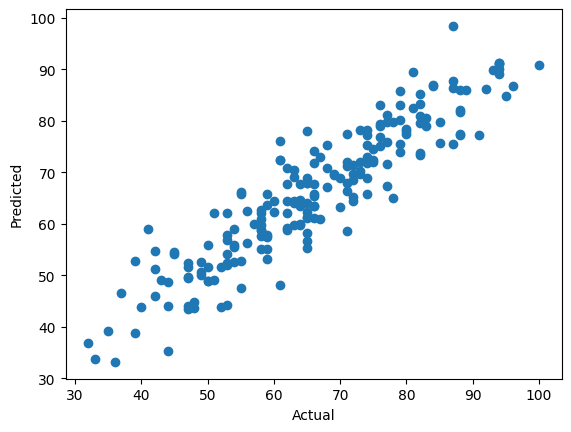

In [25]:
#Plot y_pred, y_test
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

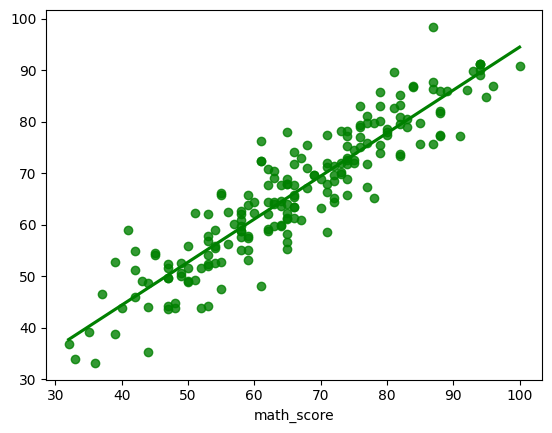

In [27]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='green');

In [29]:
## Difference between the actual and the predcited values:

pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
923,54,55.452862,-1.452862
921,35,39.128798,-4.128798
516,74,78.193371,-4.193371
87,71,66.408040,4.591960
879,64,67.765544,-3.765544
...,...,...,...
711,80,78.505571,1.494429
517,66,67.664903,-1.664903
984,74,72.480019,1.519981
886,93,89.796561,3.203439
